<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A1%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. На основе учебного ноутбука проведите финальную подготовку данных. Измените количество сегментирующих классов с 16 на 7:
    * 0_класс — FLOOR;
    * 1_класс — CEILING;
    * 2_класс — WALL;
    * 3_класс — APERTURE, DOOR, WINDOW;
    * 4_класс — COLUMN, RAILINGS, LADDER;
    * 5_класс — INVENTORY;
    * 6_класс — LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE.

2. Реализуйте сегментацию базы «Стройка» на основе модели PSPnet. Статья для изучения: Pyramid Scene Parsing Network (https://hszhao.github.io/projects/pspnet/).

**Важно!**
Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения. Для предотвращения переполнения ОЗУ может помочь библиотека gc. Вставьте строчку gc.collect() в цикл ваших экспериментов для сбора и удаления временных данных (кеш)."

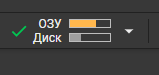



Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка


### Импорт библиотек

In [1]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [2]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:10<00:00, 21.0MB/s]


## Решение

In [10]:
# Ваше решение
#Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256             # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки
# Цвета пикселов сегментированных изображений

FLOOR = (100, 100, 100)         # Пол (серый)
CEILING = (0, 0, 100)           # Потолок (синий)
WALL = (0, 100, 0)              # Стена (зеленый)
COLUMN = (100, 0, 0)            # Колонна (красный)
APERTURE = (0, 100, 100)        # Проем (темно-бирюзовый)
DOOR = (100, 0, 100)            # Дверь (бордовый)
WINDOW = (100, 100, 0)          # Окно (золотой)
EXTERNAL = (200, 200, 200)      # Внешний мир (светло-серый)
RAILINGS = (0, 200, 0)          # Перила (светло-зеленый)
BATTERY = (200, 0, 0)           # Батареи (светло-красный)
PEOPLE = (0, 200, 200)          # Люди (бирюзовый)
LADDER = (0, 0, 200)            # Лестница (светло-синий)
INVENTORY = (200, 0, 200)       # Инвентарь (розовый)
LAMP = (200, 200, 0)            # Лампа (желтый)
WIRE = (0, 100, 200)            # Провод (голубой)
BEAM = (100, 0, 200)            # Балка (фиолетовый)

In [11]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.31c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


In [12]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.26c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


In [13]:
CLASS_LABELS = (FLOOR, CEILING, WALL, COLUMN, APERTURE, DOOR, WINDOW, EXTERNAL, RAILINGS, BATTERY, PEOPLE, LADDER, INVENTORY, LAMP, WIRE, BEAM)
# 0_класс — FLOOR; 1_класс — CEILING; 2_класс — WALL; 3_класс — APERTURE, DOOR, WINDOW;
# 4_класс — COLUMN, RAILINGS, LADDER; 5_класс — INVENTORY;
# 6_класс — LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE

CLASS_LABELS_2 = ((FLOOR), (CEILING), (WALL), (APERTURE, DOOR, WINDOW), (COLUMN, RAILINGS, LADDER), (INVENTORY), (LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE))
CLASS_COUNT=len(CLASS_LABELS_2)


In [14]:
# Функция преобразования цветного сегментированного изображения в метки классов

def rgb_to_labels(image_list  # список цветных изображений
                 ):

    result = []

    # Для всех картинок в списке:
    for d in image_list:
        sample = np.array(d)
        # Создание пустой 1-канальной картики
        y = np.zeros((IMG_WIDTH, IMG_HEIGHT, 1), dtype='uint8')

        # По всем классам:
        for i, cl_gr in enumerate(CLASS_LABELS_2):
            for j, cl in enumerate(cl_gr):
                # Нахождение 3-х канальных пикселей классов и занесение метки класса
                y[np.where(np.all(sample == CLASS_LABELS[j], axis=-1))] = i

        result.append(y)

    return np.array(result)

In [15]:
# Функция преобразования тензора меток класса в цветное сегметрированное изображение

def labels_to_rgb(image_list  # список одноканальных изображений
                 ):

    result = []

    # Для всех картинок в списке:
    for y in image_list:
        # Создание пустой цветной картики
        temp = np.zeros((IMG_WIDTH, IMG_HEIGHT, 3), dtype='uint8')

        # По всем классам:
        for i, cl_gr in enumerate(CLASS_LABELS_2):
            # Нахождение пикселов класса и заполнение цветом из CLASS_LABELS[i]
            temp[np.where(np.all(y==i, axis=-1))] = CLASS_LABELS_2[i][0]

        result.append(temp)

    return np.array(result)

In [16]:
# Формирование обучающей выборки

x_train = []                          # Cписок под обучающую выборку

for img in train_images:              # Для всех изображений выборки:
    x = image.img_to_array(img)       # Перевод изображения в numpy-массив формы: высота x ширина x количество каналов
    x_train.append(x)                 # Добавление элемента в x_train

x_train = np.array(x_train)           # Перевод всей выборки в numpy
print(x_train.shape)                  # Форма x_train

(1900, 192, 256, 3)


In [17]:
# Формирование проверочной выборки

x_val = []                            # Cписок под проверочную выборку

for img in val_images:                # Для всех изображений выборки:
    x = image.img_to_array(img)       # Перевод изображения в numpy-массив формы: высота x ширина x количество каналов
    x_val.append(x)                   # Добавление элемента в x_train

x_val = np.array(x_val)               # Перевод всей выборки в numpy
print(x_val.shape)

(100, 192, 256, 3)


In [18]:
# Преобразование сегментов в метки классов

y_train = rgb_to_labels(train_segments)
y_val = rgb_to_labels(val_segments)

print(y_train.shape)
print(y_val.shape)

(1900, 192, 256, 1)
(100, 192, 256, 1)


In [19]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, UpSampling2D, concatenate, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

class PPMLayer(tf.keras.layers.Layer):
    def __init__(self, bin_sizes=[1, 2, 3, 6], **kwargs):
        super(PPMLayer, self).__init__(**kwargs)
        self.bin_sizes = bin_sizes
        self.convs = []

        for i in range(len(bin_sizes)):
            self.convs.append(
                Conv2D(128, (1, 1), padding="same", name=f"ppm_conv_{i}")
            )
            self.convs.append(BatchNormalization())
            self.convs.append(Activation("relu"))

    def call(self, inputs):
        h = tf.shape(inputs)[1]
        w = tf.shape(inputs)[2]

        concat_list = [inputs]

        for i, bin_size in enumerate(self.bin_sizes):
            # уменьшение
            x = tf.image.resize(inputs, (bin_size, bin_size), method="bilinear")

            # сверточный блок
            idx = i * 3
            x = self.convs[idx](x)
            x = self.convs[idx + 1](x)
            x = self.convs[idx + 2](x)

            # возврат к исходному размеру
            x = tf.image.resize(x, (h, w), method="bilinear")

            concat_list.append(x)

        return tf.concat(concat_list, axis=-1)

def conv_block(x, filters, name):
    """Conv-BN-ReLU блок"""
    x = Conv2D(filters, (3, 3), padding='same', name=name+'_conv')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def pyramid_pooling_module(input_tensor, bin_sizes=[1, 2, 3, 6]):
    """PPM через AveragePooling2D + UpSampling2D"""
    concat_list = [input_tensor]

    # статические размеры (например 32x32), если они известны
    input_h = input_tensor.shape[1]
    input_w = input_tensor.shape[2]

    for i, bin_size in enumerate(bin_sizes):
        # Сжимаем через AveragePooling2D (получаем примерно bin_size x bin_size)
        x = AveragePooling2D(pool_size=(input_h // bin_size, input_w // bin_size),
                             strides=(input_h // bin_size, input_w // bin_size),
                             padding="same")(input_tensor)

        x = Conv2D(128, (1, 1), padding='same', name=f'ppm_conv_{i}')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)

        # Растягиваем обратно с фиксированным коэффициентом
        x = UpSampling2D(size=(input_h // bin_size, input_w // bin_size),
                         interpolation="bilinear")(x)

        concat_list.append(x)

    return concatenate(concat_list)


def pspnet(class_count, input_shape=(256, 256, 3)):
    img_input = Input(input_shape)

    # Encoder (пример — как у тебя)
    x = conv_block(img_input, 64, 'block1_1')
    x = conv_block(x, 64, 'block1_2')
    x = MaxPooling2D()(x)

    x = conv_block(x, 128, 'block2_1')
    x = conv_block(x, 128, 'block2_2')
    x = MaxPooling2D()(x)

    x = conv_block(x, 256, 'block3_1')
    x = conv_block(x, 256, 'block3_2')
    x = conv_block(x, 256, 'block3_3')
    x = MaxPooling2D()(x)

    x = conv_block(x, 512, 'block4_1')
    x = conv_block(x, 512, 'block4_2')
    x = conv_block(x, 512, 'block4_3')

    # PPM через кастомный слой
    x = PPMLayer()(x)

    # Bottleneck
    x = conv_block(x, 512, 'bottleneck_1')
    x = conv_block(x, 512, 'bottleneck_2')

    # Апсемплинг до размера входа
    x = UpSampling2D(size=(8, 8), interpolation="bilinear")(x)

    # Финальный слой
    x = Conv2D(class_count, (1, 1), padding='same')(x)
    x = Activation('softmax')(x)

    model = Model(img_input, x)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )
    return model



In [20]:
# Создание модели и вывод сводки по архитектуре

model_pspnet = pspnet(CLASS_COUNT,
                  (IMG_WIDTH, IMG_HEIGHT, 3))

model_pspnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_1_conv (Conv2D)          │ (None, 192, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 192, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 192, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_2_conv (Conv2D)          │ (None, 192, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 192, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_1_conv (Conv2D)          │ (None, 96, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 96, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_2_conv (Conv2D)          │ (None, 96, 128, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 96, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_1_conv (Conv2D)          │ (None, 48, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 48, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_2_conv (Conv2D)          │ (None, 48, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 48, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_3_conv (Conv2D)          │ (None, 48, 64, 256)    │       590,08

 Total params: 14,997,319 (57.21 MB)

 Trainable params: 14,988,871 (57.18 MB)

 Non-trainable params: 8,448 (33.00 KB)

In [21]:
# Обучение модели

history = model_pspnet.fit(x_train, y_train,
                         epochs=5, batch_size=8,
                         validation_data=(x_val, y_val))

Epoch 1/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 159s 498ms/step - loss: 0.7294 - sparse_categorical_accuracy: 0.7711 - val_loss: 0.6044 - val_sparse_categorical_accuracy: 0.7261
Epoch 2/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 135s 351ms/step - loss: 0.3609 - sparse_categorical_accuracy: 0.8450 - val_loss: 0.6121 - val_sparse_categorical_accuracy: 0.6758
Epoch 3/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 84s 351ms/step - loss: 0.3359 - sparse_categorical_accuracy: 0.8546 - val_loss: 0.5948 - val_sparse_categorical_accuracy: 0.6998
Epoch 4/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 143s 354ms/step - loss: 0.3170 - sparse_categorical_accuracy: 0.8651 - val_loss: 0.5561 - val_sparse_categorical_accuracy: 0.7325
Epoch 5/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 143s 358ms/step - loss: 0.3051 - sparse_categorical_accuracy: 0.8708 - val_loss: 0.5141 - val_sparse_categorical_accuracy: 0.7625


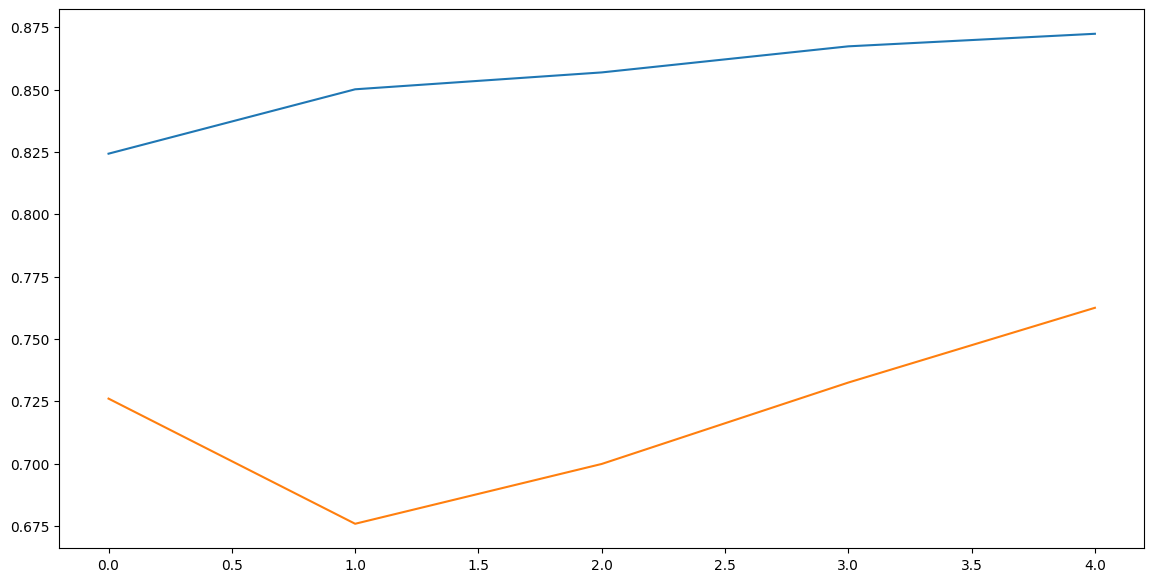

In [22]:
# Отображение графиков обучения модели

plt.figure(figsize=(14, 7))
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.show()

In [23]:
# Функция визуализации процесса сегментации изображений

def process_images(model,        # обученная модель
                   count = 1     # количество случайных картинок для сегментации
                   ):

    # Генерация случайного списка индексов в количестве count между (0, len(x_val)
    indexes = np.random.randint(0, len(x_val), count)

    # Вычисление предсказания сети для картинок с отобранными индексами
    predict = np.argmax(model.predict(x_val[indexes]), axis=-1)

    # Подготовка цветов классов для отрисовки предсказания
    orig = labels_to_rgb(predict[..., None])
    fig, axs = plt.subplots(3, count, figsize=(25, 15))

    # Отрисовка результата работы модели
    for i in range(count):
        # Отображение на графике в первой линии предсказания модели
        axs[0, 0].set_title('Результат работы модели:')
        axs[0, i].imshow(orig[i])
        axs[0, i].axis('off')

        # Отображение на графике во второй линии сегментированного изображения из y_val
        axs[1, 0].set_title('Оригинальное сегментированное')
        axs[1, i].imshow(val_segments[indexes[i]])
        axs[1 ,i].axis('off')

        # Отображение на графике в третьей линии оригинального изображения
        axs[2, 0].set_title('Оригинальное изображение')
        axs[2, i].imshow(val_images[indexes[i]])
        axs[2 ,i].axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


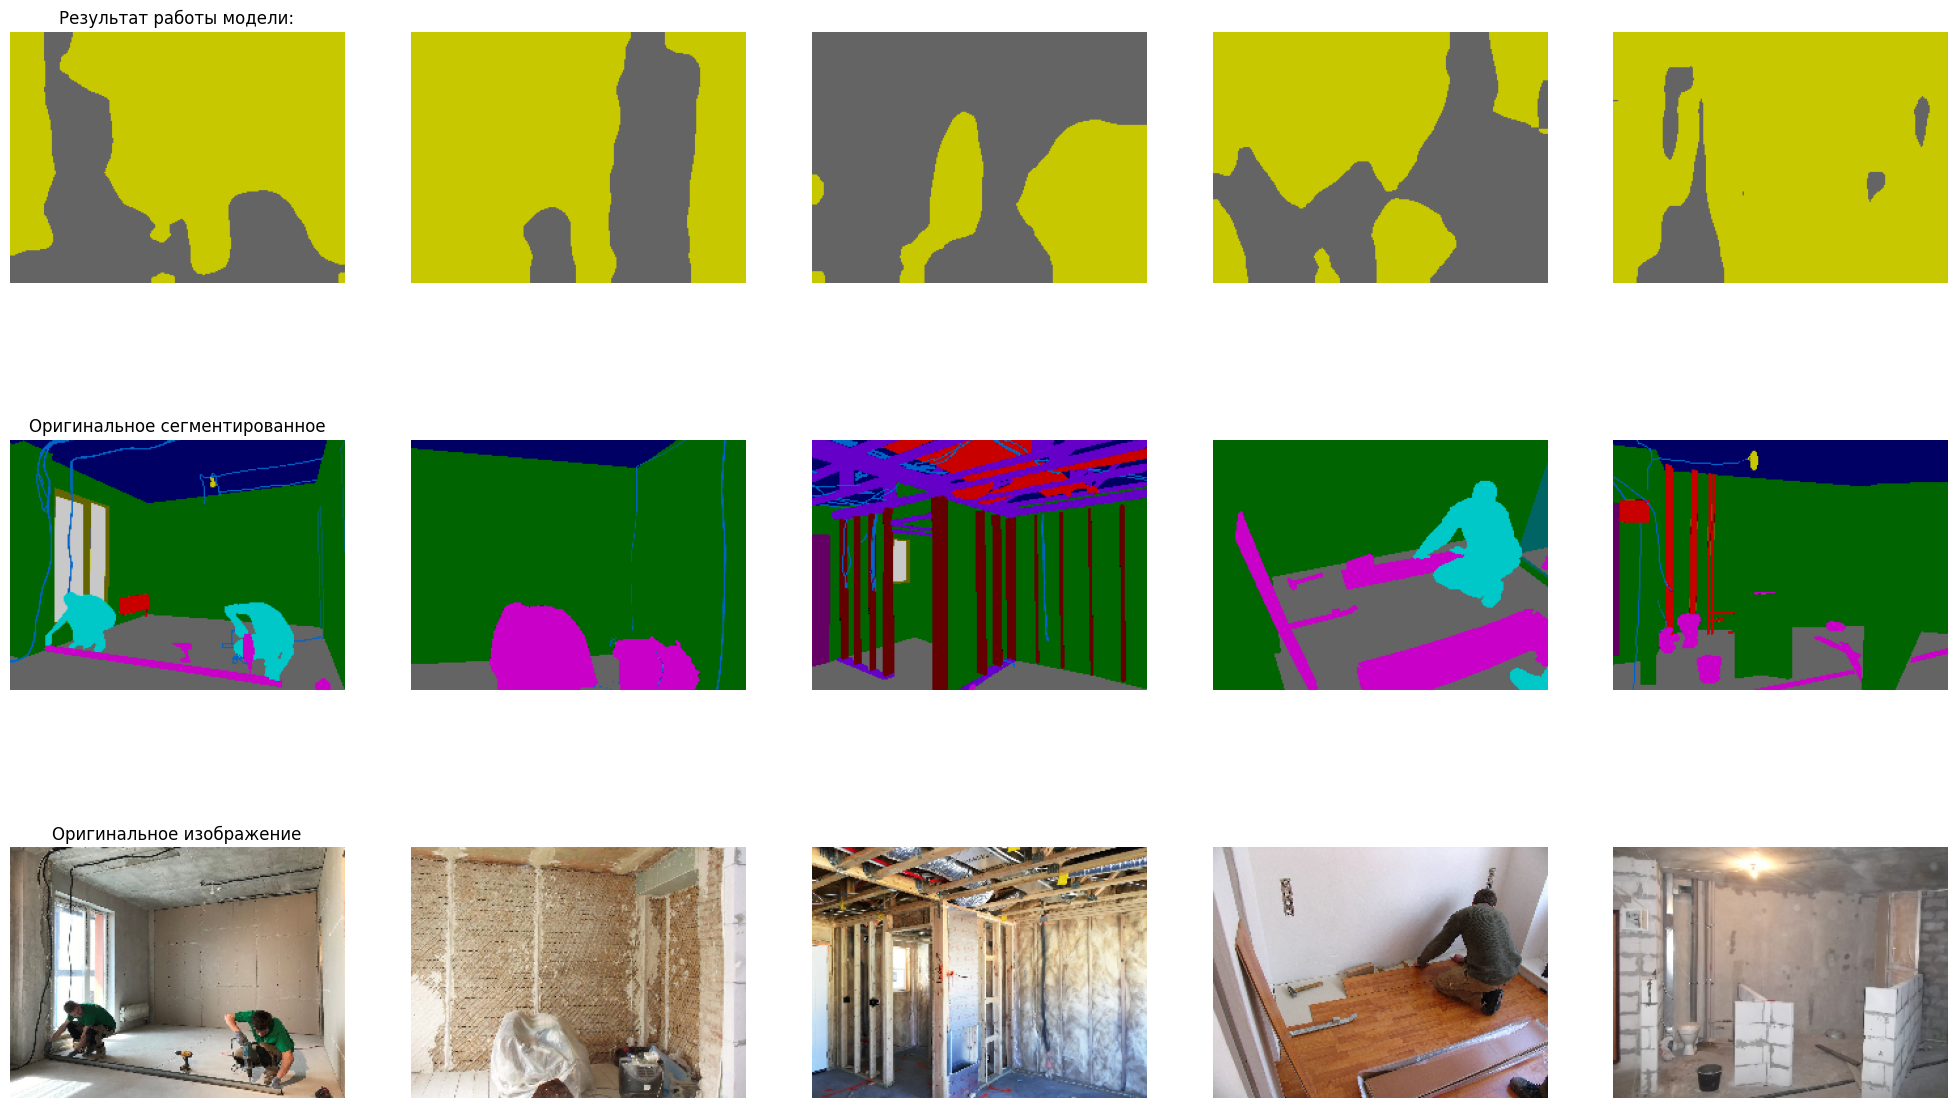

In [25]:
# Отображение результатов работы модели

process_images(model_pspnet, 5)